Cell for synchronisation

In [1]:
%load_ext autoreload
%autoreload 2

Experiment set up

Feature extraction

In [6]:
import pickle 
from pathlib import Path
import numpy as np
from src.feature_generation import pool_features
dir = Path("/idiap/temp/adeych/data")
with open(dir / "feature_banks" / "perch2-bags.pkl", "rb") as f:
    X_bags_per = pickle.load(f)
with open(dir / "feature_banks" / "effnetb0-bags.pkl", "rb") as f:
    X_bags_eff = pickle.load(f)
with open(dir / "feature_banks" / "NLM-bags.pkl", "rb") as f:
    X_bags_nlm = pickle.load(f)

y = np.load(dir / "feature_banks" / "labels.npy")
X_per = pool_features(pool_features(X_bags_per,encoder = 'perch2'),encoder = 'perch2',windows = True)
X_eff = pool_features(pool_features(X_bags_eff,encoder = 'effnetb0'),encoder = 'effnetb0',windows = True)
X_nlm = pool_features(pool_features(X_bags_nlm,encoder = 'NLM_BEATs'),encoder = 'NLM_BEATs',windows = True)

In [8]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

Results generation

In [9]:
from src.encoder_comparison import linear_probe_tuned
results_per = linear_probe_tuned(X_per, y, n_split_out=5, n_split_in=5, num_trials=5, random_state=42)


Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5


    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Logistic Regression
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Logistic Regression
    Evaluating fold 1/5


KeyboardInterrupt: 

Experiment analysis

In [2]:
import pickle 
from pathlib import Path
import numpy as np
from src.feature_generation import pool_features
dir = Path("/idiap/temp/adeych/results/encoder_exp")
with open(dir / "enc_perch2_results.pkl", "rb") as f:
    results_per = pickle.load(f)
with open(dir / "enc_effnetb0_results.pkl", "rb") as f:
    results_eff = pickle.load(f)
with open(dir / "enc_NLM_BEATs_results.pkl", "rb") as f:
    results_nlm = pickle.load(f)

/idiap/temp/adeych/conda/envs/temp-env-4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
from src.tables import generate_encoder_latex_table,process_encoder_folds_to_table

results_dict = {
    'ESP-EffNetB0' : results_eff,
    'NatureLM-BEATs' : results_nlm,
    'Perch 2.0' : results_per,
}
lat_code = process_encoder_folds_to_table(results_dict)

In [11]:
with open("encoder_table.tex", "w", encoding="utf-8") as f:
    f.write(lat_code)

Friedman test p-value: 2.1887e-11


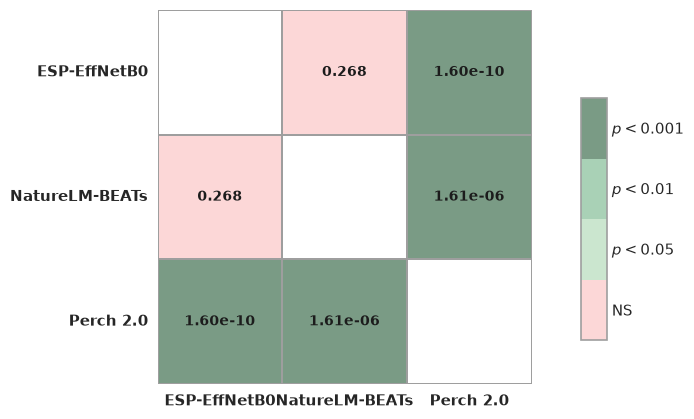

In [13]:
from src.statistical_tests import perform_and_plot_nemenyi
label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']
perform_and_plot_nemenyi(results_dict, label_names=label_names)

In [14]:
from src.statistical_tests import perform_encoder_statistical_analysis
df_stat = perform_encoder_statistical_analysis(results_dict, label_names=label_names)

=== Statistical Setup ===
Number of perfectly matched Blocks (N): 500
Treatments (Encoders mapped): ['ESP-EffNetB0', 'NatureLM-BEATs', 'Perch 2.0']

=== Friedman Test Results ===
Friedman $\chi^2$ Statistic: 49.0902
p-value: 2.1887e-11
Result: Significant difference detected (p < 0.05). Proceeding to Post-Hoc Nemenyi Test.

=== Mean Ranks (Lower is Better/Rank 1 is Top) ===
• ESP-EffNetB0: 2.171
• NatureLM-BEATs: 2.073
• Perch 2.0: 1.756

Calculated Nemenyi Critical Difference (CD): 0.2096

=== Nemenyi Pairwise p-value Matrix ===
                ESP-EffNetB0  NatureLM-BEATs  Perch 2.0
ESP-EffNetB0          1.0000          0.2679 1.5955e-10
NatureLM-BEATs        0.2679          1.0000 1.6097e-06
Perch 2.0         1.5955e-10      1.6097e-06     1.0000

*Interpretation: Pairwise cells show exact p-values. If p < 0.05, performance difference is significant.


=== Statistical Setup ===
Number of perfectly matched Blocks (N): 125
Algorithms evaluated: ['SVM', 'Logistic Regression', 'Random Forest', 'MLP']

=== Algorithm Ranks (Lower is Better) ===
1. MLP                       Mean Rank: 2.1680
2. Logistic Regression       Mean Rank: 2.4400
3. SVM                       Mean Rank: 2.5520
4. Random Forest             Mean Rank: 2.8400

=== Friedman Test Results ===
Friedman chi-square Statistic: 18.6638
p-value: 3.2083e-04
Result: Significant differences detected. Proceeding to Post-Hoc Nemenyi Test.



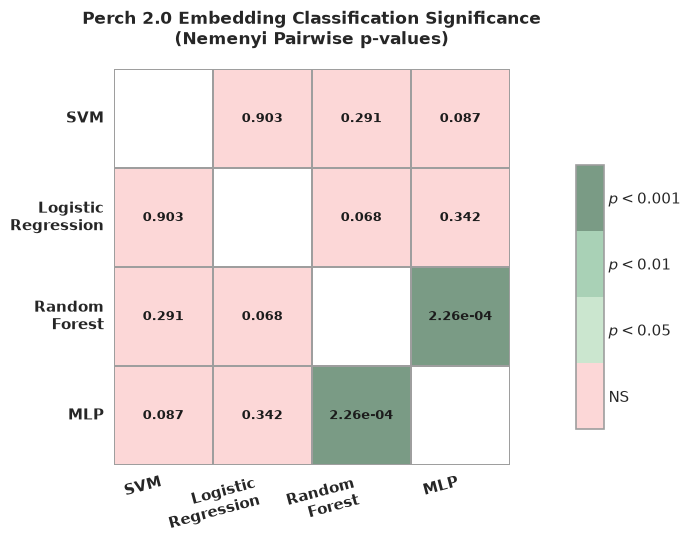

In [15]:
from src.statistical_tests import evaluate_and_plot_linear_probe_algorithms
evaluate_and_plot_linear_probe_algorithms(results_per, label_names=label_names)